##1 — Imports & Setup

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, ConstantKernel as C
from scipy.optimize import brentq
import warnings
warnings.filterwarnings("ignore")

# Publication-quality plot settings
mpl.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "serif",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
})
print(" All libraries loaded successfully.")

 All libraries loaded successfully.


##2 — Load Cosmic Chronometer Dataset

In [15]:
# Source: Magana et al. 2018 (arXiv:1802.01505) — 31 CC data points

z_data = np.array([
    0.07, 0.09, 0.12, 0.17, 0.1791, 0.1993, 0.20,
    0.27, 0.28, 0.3519, 0.3802, 0.40, 0.4004, 0.4247,
    0.4497, 0.47, 0.4783, 0.48, 0.5929, 0.6797, 0.7812,
    0.8754, 0.88, 0.9, 1.037, 1.30, 1.363, 1.43,
    1.53, 1.75, 1.965
])
Hz_data = np.array([
    69.0, 69.0, 68.6, 83.0, 75.0, 75.0, 72.9,
    77.0, 88.8, 83.0, 83.0, 95.0, 77.0, 87.1,
    92.8, 89.0, 80.9, 97.0, 104.0, 92.0, 105.0,
    125.0, 90.0, 117.0, 154.0, 168.0, 160.0, 177.0,
    140.0, 202.0, 186.5
])
sigma_data = np.array([
    19.6, 12.0, 26.2, 8.0, 4.0, 5.0, 29.6,
    14.0, 36.6, 14.0, 13.5, 17.0, 10.2, 11.2,
    12.9, 49.6, 9.0, 62.0, 13.0, 8.0, 12.0,
    17.0, 40.0, 23.0, 20.0, 17.0, 33.6, 18.0,
    14.0, 40.0, 50.4
])

X = z_data.reshape(-1, 1)
y = Hz_data
y_err = sigma_data

print(f" Dataset loaded: {len(z_data)} data points")
print(f"   Redshift range: z = {z_data.min():.3f} to {z_data.max():.3f}")

 Dataset loaded: 31 data points
   Redshift range: z = 0.070 to 1.965


##3 — EDA Plot (Figure 1)

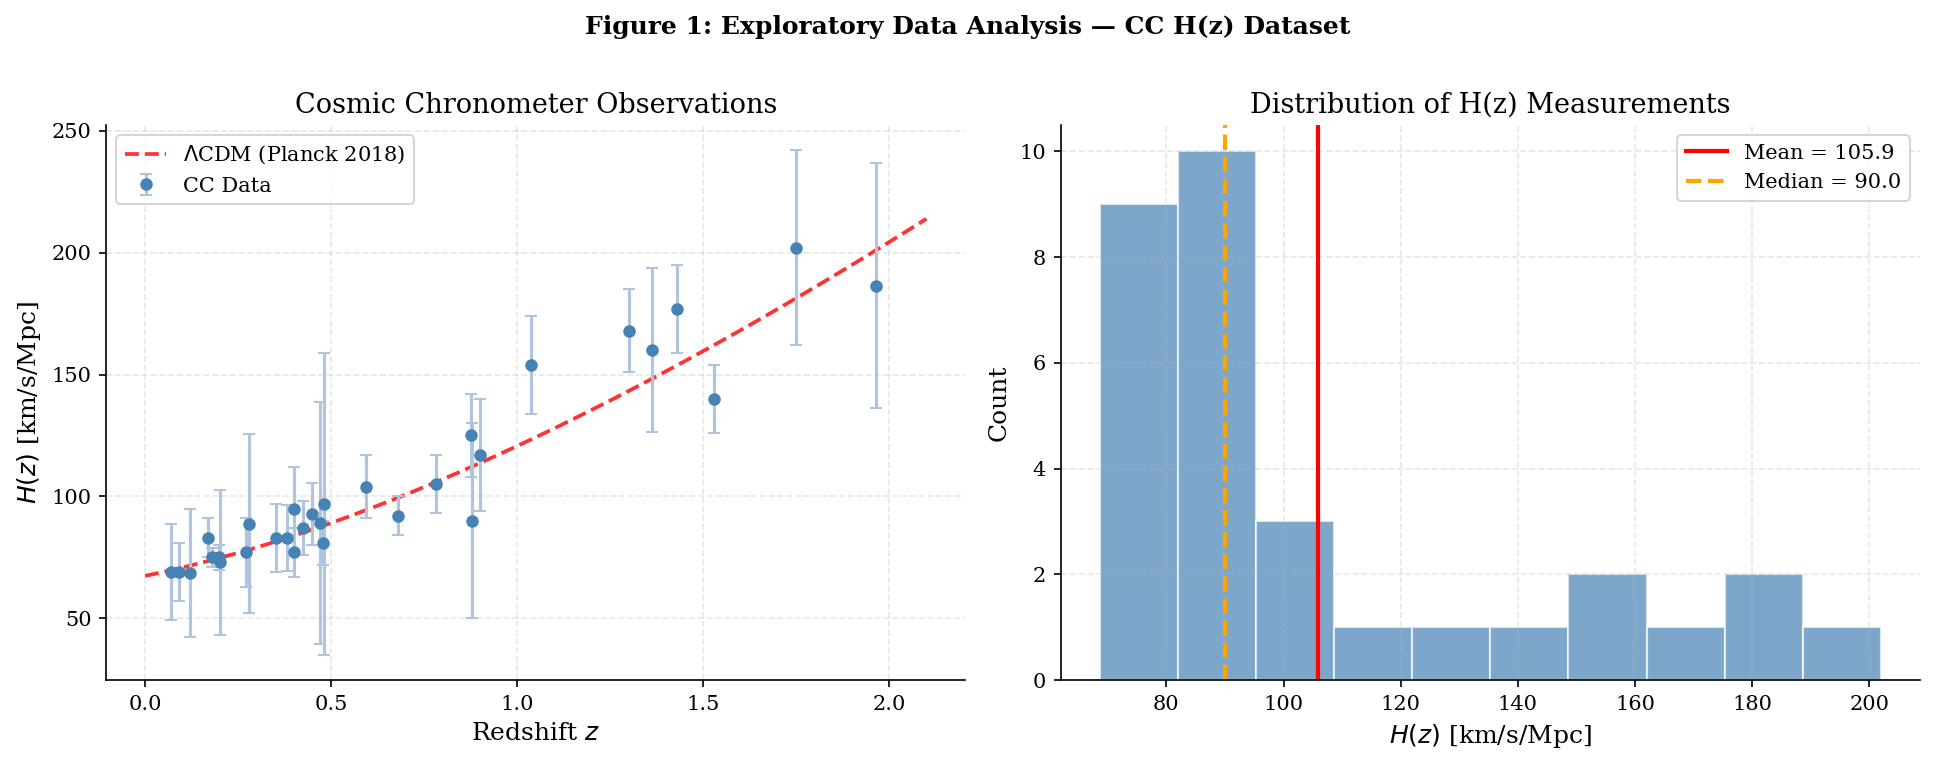

In [3]:
H0_planck = 67.4
Omega_m = 0.315
Omega_L = 1 - Omega_m
z_ref = np.linspace(0, 2.1, 300)
Hz_lcdm = H0_planck * np.sqrt(Omega_m * (1 + z_ref)**3 + Omega_L)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.errorbar(z_data, Hz_data, yerr=sigma_data,
            fmt='o', color='steelblue', ecolor='lightsteelblue',
            elinewidth=1.5, capsize=3, ms=5, label='CC Data', zorder=3)
ax.plot(z_ref, Hz_lcdm, 'r--', lw=1.8, alpha=0.8,
        label=r'$\Lambda$CDM (Planck 2018)')
ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'$H(z)$ [km/s/Mpc]')
ax.set_title('Cosmic Chronometer Observations')
ax.legend()

ax2 = axes[1]
ax2.hist(Hz_data, bins=10, color='steelblue', alpha=0.7, edgecolor='white')
ax2.axvline(np.mean(Hz_data), color='red', lw=2, label=f'Mean = {np.mean(Hz_data):.1f}')
ax2.axvline(np.median(Hz_data), color='orange', lw=2, linestyle='--',
            label=f'Median = {np.median(Hz_data):.1f}')
ax2.set_xlabel(r'$H(z)$ [km/s/Mpc]')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of H(z) Measurements')
ax2.legend()

plt.suptitle('Figure 1: Exploratory Data Analysis — CC H(z) Dataset',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Figure1_EDA.png', bbox_inches='tight', dpi=150)
plt.show()

##4 — Kernels and mean

In [17]:
# --- ΛCDM Mean Function ---
H0_planck = 67.4
Omega_m   = 0.315
Omega_L   = 1 - Omega_m

def lcdm_mean(z_array):
    return H0_planck * np.sqrt(Omega_m * (1 + z_array)**3 + Omega_L)

# --- Kernel Definitions ---
kernels = {
    "RBF": C(100.0, (1e-2, 1e4)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 10.0)),
    "Matern": C(100.0, (1e-2, 1e4)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 10.0), nu=2.5),
    "RatQuad": C(100.0, (1e-2, 1e4)) * RationalQuadratic(length_scale=1.0, alpha=1.0,
                                                         length_scale_bounds=(1e-2, 10.0),
                                                         alpha_bounds=(1e-2, 1e2)),
}

print(" Kernels defined:")
for name, k in kernels.items():
    print(f"{name:10s} → {k}")

print("\n ΛCDM mean function defined.")
print(f"At z=0.0 : {lcdm_mean(0.0):.2f}")
print(f"At z=0.5 : {lcdm_mean(0.5):.2f}")
print(f"At z=1.0 : {lcdm_mean(1.0):.2f}")
print(f"At z=2.0 : {lcdm_mean(2.0):.2f}")

 Kernels defined:
RBF        → 10**2 * RBF(length_scale=1)
Matern     → 10**2 * Matern(length_scale=1, nu=2.5)
RatQuad    → 10**2 * RationalQuadratic(alpha=1, length_scale=1)

 ΛCDM mean function defined.
At z=0.0 : 67.40
At z=0.5 : 89.11
At z=1.0 : 120.66
At z=2.0 : 204.32


##5 — Fit zero-mean GPR

In [18]:
alpha_noise = sigma_data**2
gpr_zero = {}

print("Fitting GPR with ZERO mean function...")
print("-" * 45)

for name, kernel in kernels.items():
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=alpha_noise,
        n_restarts_optimizer=15,
        normalize_y=True
    )
    gpr.fit(X, y)
    gpr_zero[name] = gpr

    lml = gpr.log_marginal_likelihood_value_
    print(f"{name:10s} | LML = {lml:8.3f} | Optimized kernel: {gpr.kernel_}")

print("\n Zero mean GPR fitting complete.")

Fitting GPR with ZERO mean function...
---------------------------------------------
RBF        | LML = -116.857 | Optimized kernel: 0.1**2 * RBF(length_scale=0.484)
Matern     | LML = -116.857 | Optimized kernel: 0.1**2 * Matern(length_scale=0.533, nu=2.5)
RatQuad    | LML = -116.857 | Optimized kernel: 0.1**2 * RationalQuadratic(alpha=1.6, length_scale=0.547)

 Zero mean GPR fitting complete.


##6 — Fit ΛCDM-mean GPR

In [19]:
y_lcdm_mean = lcdm_mean(z_data)
y_residuals = y - y_lcdm_mean

gpr_lcdm = {}

print("Fitting GPR with ΛCDM mean function (residual approach)...")
print("-" * 55)

for name, kernel in kernels.items():
    gpr = GaussianProcessRegressor(
        kernel=kernel,
        alpha=alpha_noise,
        n_restarts_optimizer=15,
        normalize_y=True
    )
    gpr.fit(X, y_residuals)
    gpr_lcdm[name] = gpr

    lml = gpr.log_marginal_likelihood_value_
    print(f"{name:10s} | LML = {lml:8.3f} | Optimized kernel: {gpr.kernel_}")

print("\n ΛCDM mean GPR fitting complete.")
print(f"Total models fitted = {len(gpr_zero) + len(gpr_lcdm)}")

Fitting GPR with ΛCDM mean function (residual approach)...
-------------------------------------------------------
RBF        | LML = -116.839 | Optimized kernel: 0.1**2 * RBF(length_scale=10)
Matern     | LML = -116.839 | Optimized kernel: 0.1**2 * Matern(length_scale=10, nu=2.5)
RatQuad    | LML = -116.839 | Optimized kernel: 0.1**2 * RationalQuadratic(alpha=2.03, length_scale=10)

 ΛCDM mean GPR fitting complete.
Total models fitted = 6


##7 — Figure 2: Zero Mean Reconstructions

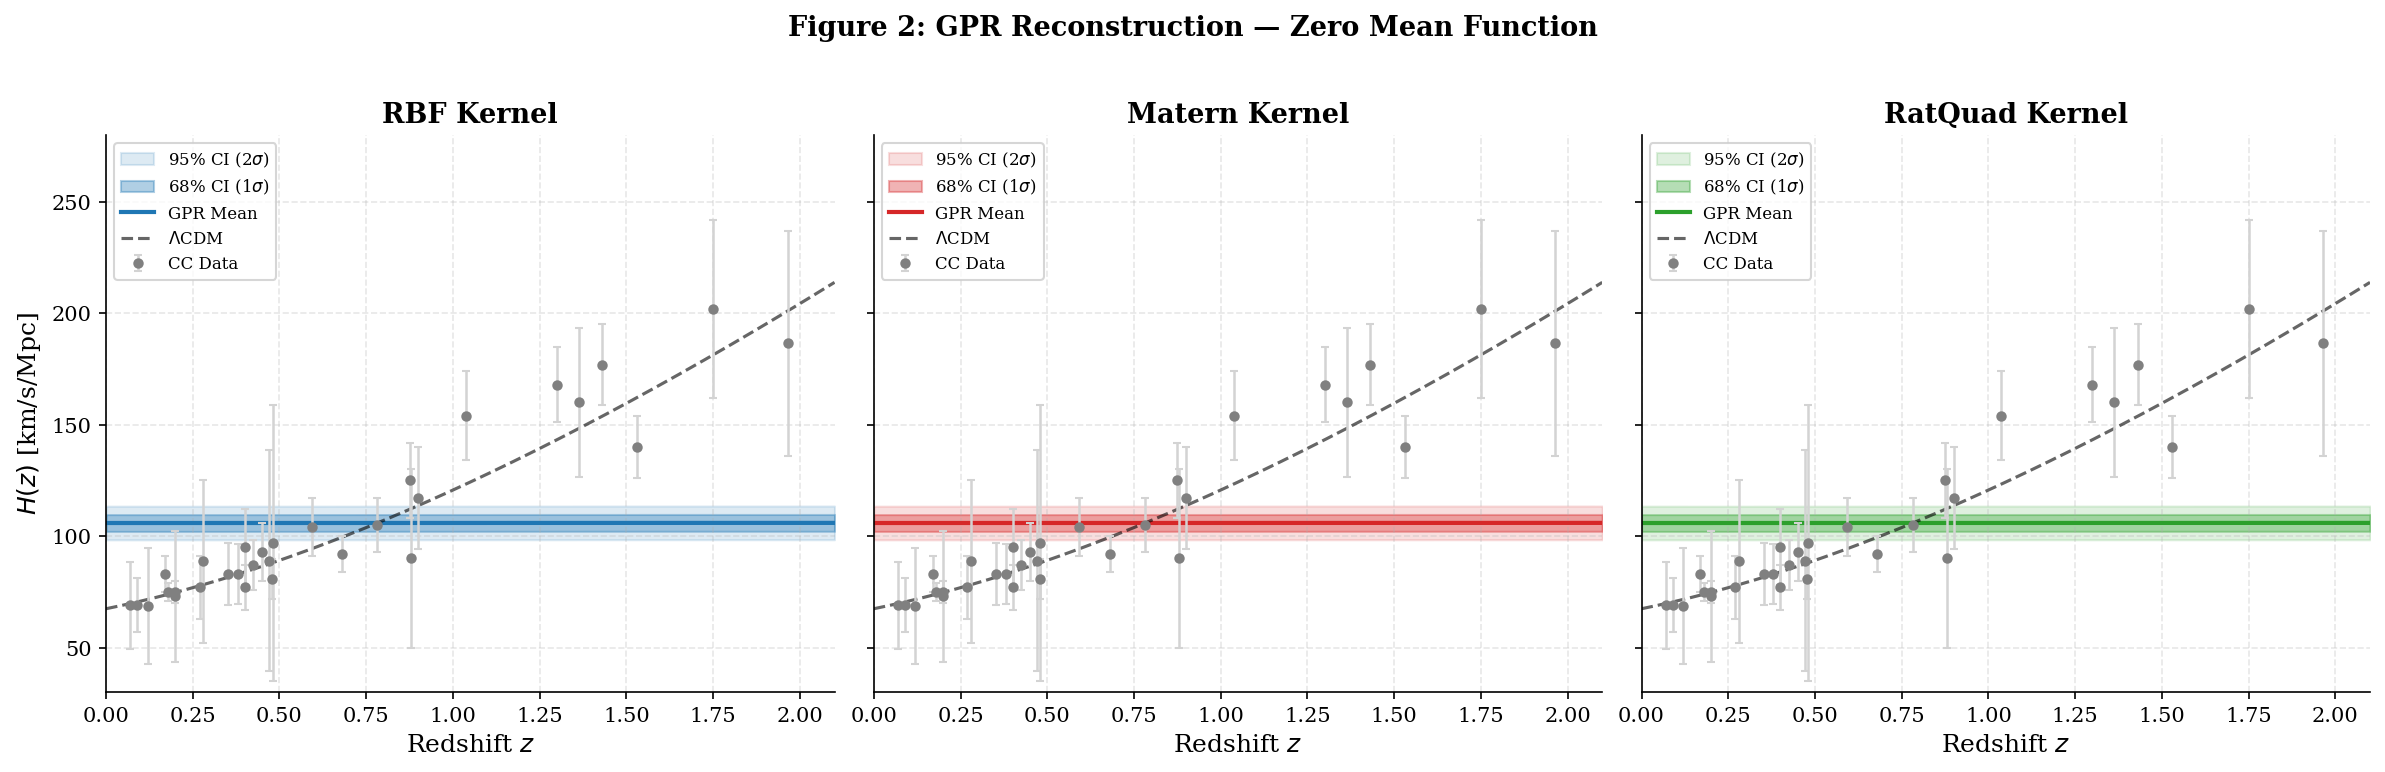

 Figure 2 saved.


In [20]:
z_pred    = np.linspace(0.0, 2.1, 500).reshape(-1, 1)
z_pred_1d = z_pred.flatten()
colors = {"RBF": "#1f77b4", "Matern": "#d62728", "RatQuad": "#2ca02c"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle("Figure 2: GPR Reconstruction — Zero Mean Function",
             fontsize=13, fontweight="bold", y=1.02)

for ax, (name, gpr) in zip(axes, gpr_zero.items()):
    mu, std = gpr.predict(z_pred, return_std=True)

    ax.fill_between(z_pred_1d, mu - 2*std, mu + 2*std,
                    alpha=0.15, color=colors[name], label=r"95% CI (2$\sigma$)")
    ax.fill_between(z_pred_1d, mu - std, mu + std,
                    alpha=0.35, color=colors[name], label=r"68% CI (1$\sigma$)")
    ax.plot(z_pred_1d, mu, color=colors[name], lw=2, label="GPR Mean")
    ax.plot(z_pred_1d, lcdm_mean(z_pred_1d), "k--", lw=1.5, alpha=0.6, label=r"$\Lambda$CDM")
    ax.errorbar(z_data, Hz_data, yerr=sigma_data,
                fmt="o", color="gray", ecolor="lightgray",
                elinewidth=1.2, capsize=2, ms=4, zorder=5, label="CC Data")

    ax.set_title(f"{name} Kernel", fontweight="bold")
    ax.set_xlabel(r"Redshift $z$")
    if ax == axes[0]:
        ax.set_ylabel(r"$H(z)$ [km/s/Mpc]")
    ax.legend(fontsize=8, loc="upper left")
    ax.set_xlim(0, 2.1)
    ax.set_ylim(30, 280)

plt.tight_layout()
plt.savefig("Figure2_ZeroMean.png", bbox_inches="tight", dpi=150)
plt.show()
print(" Figure 2 saved.")

## 8 — Figure 3: ΛCDM Mean Reconstructions

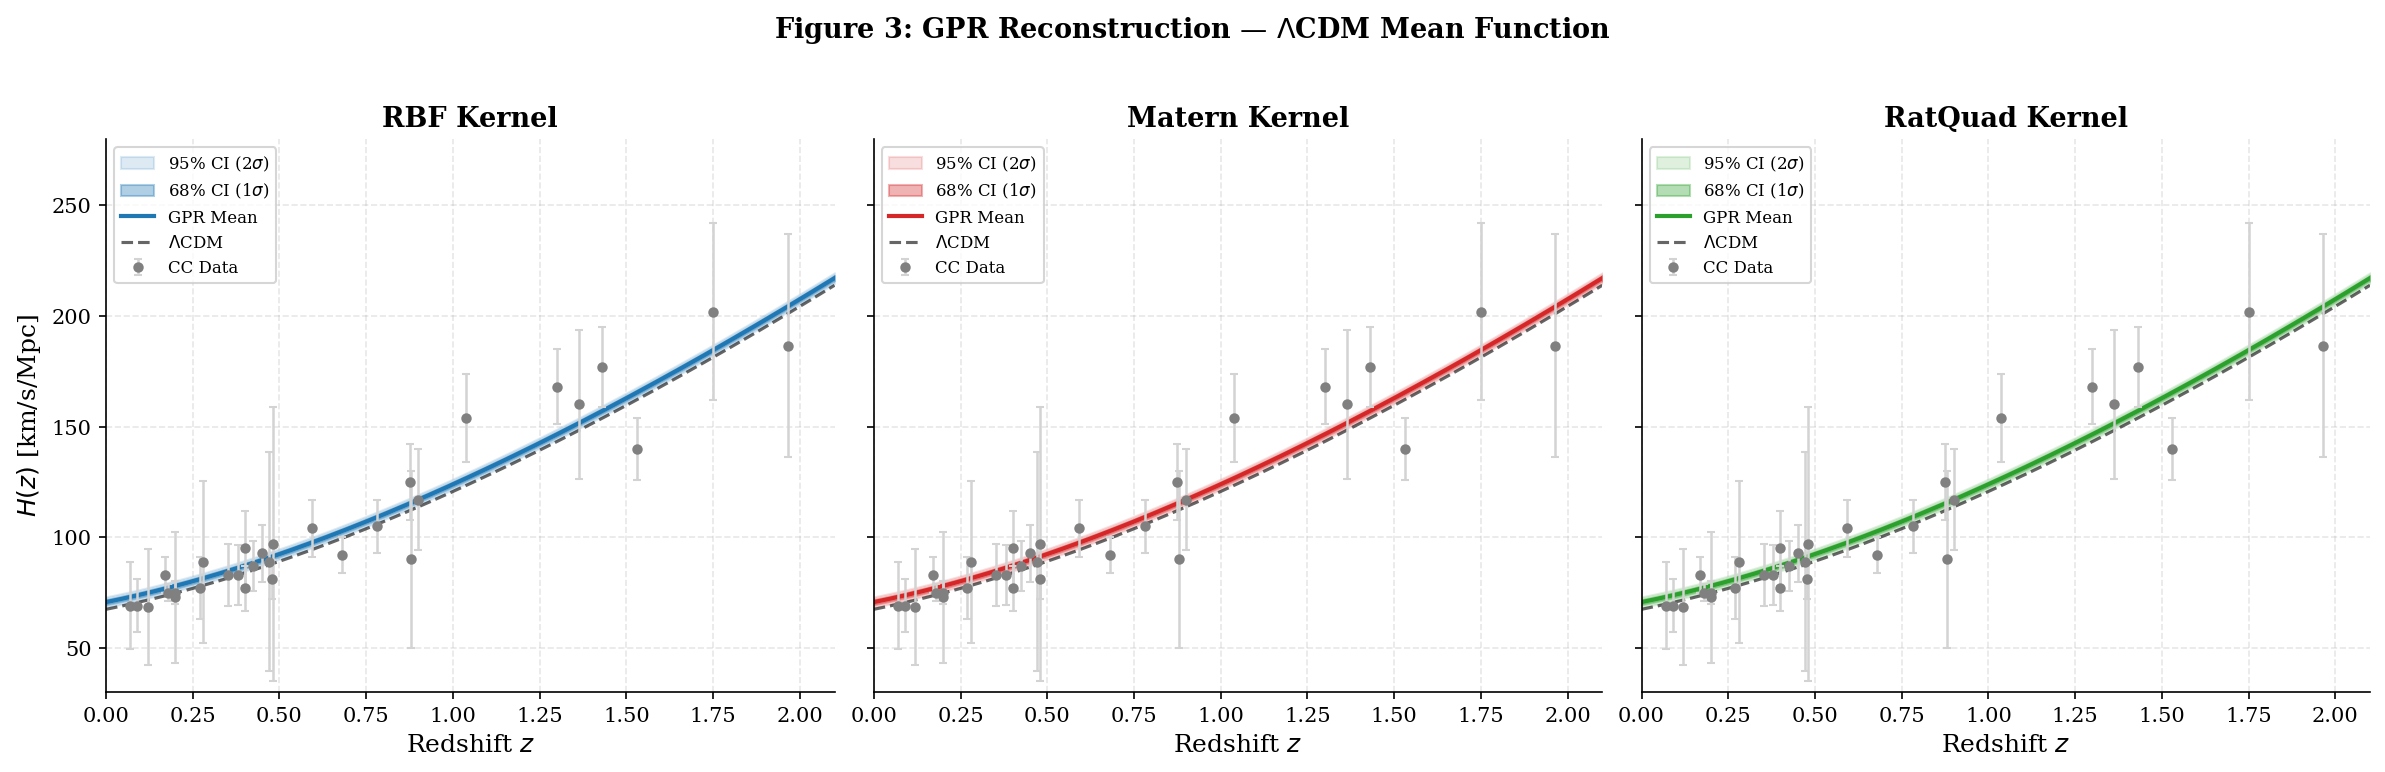

 Figure 3 saved.


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(r"Figure 3: GPR Reconstruction — $\Lambda$CDM Mean Function",
             fontsize=13, fontweight="bold", y=1.02)

for ax, (name, gpr) in zip(axes, gpr_lcdm.items()):
    mu_res, std = gpr.predict(z_pred, return_std=True)
    lcdm_pred = lcdm_mean(z_pred_1d)
    mu = mu_res + lcdm_pred

    ax.fill_between(z_pred_1d, mu - 2*std, mu + 2*std,
                    alpha=0.15, color=colors[name], label=r"95% CI (2$\sigma$)")
    ax.fill_between(z_pred_1d, mu - std, mu + std,
                    alpha=0.35, color=colors[name], label=r"68% CI (1$\sigma$)")
    ax.plot(z_pred_1d, mu, color=colors[name], lw=2, label="GPR Mean")
    ax.plot(z_pred_1d, lcdm_pred, "k--", lw=1.5, alpha=0.6, label=r"$\Lambda$CDM")
    ax.errorbar(z_data, Hz_data, yerr=sigma_data,
                fmt="o", color="gray", ecolor="lightgray",
                elinewidth=1.2, capsize=2, ms=4, zorder=5, label="CC Data")

    ax.set_title(f"{name} Kernel", fontweight="bold")
    ax.set_xlabel(r"Redshift $z$")
    if ax == axes[0]:
        ax.set_ylabel(r"$H(z)$ [km/s/Mpc]")
    ax.legend(fontsize=8, loc="upper left")
    ax.set_xlim(0, 2.1)
    ax.set_ylim(30, 280)

plt.tight_layout()
plt.savefig("Figure3_LCDMMean.png", bbox_inches="tight", dpi=150)
plt.show()
print(" Figure 3 saved.")

## 9 — Figure 4: Side-by-side Mean Comparison

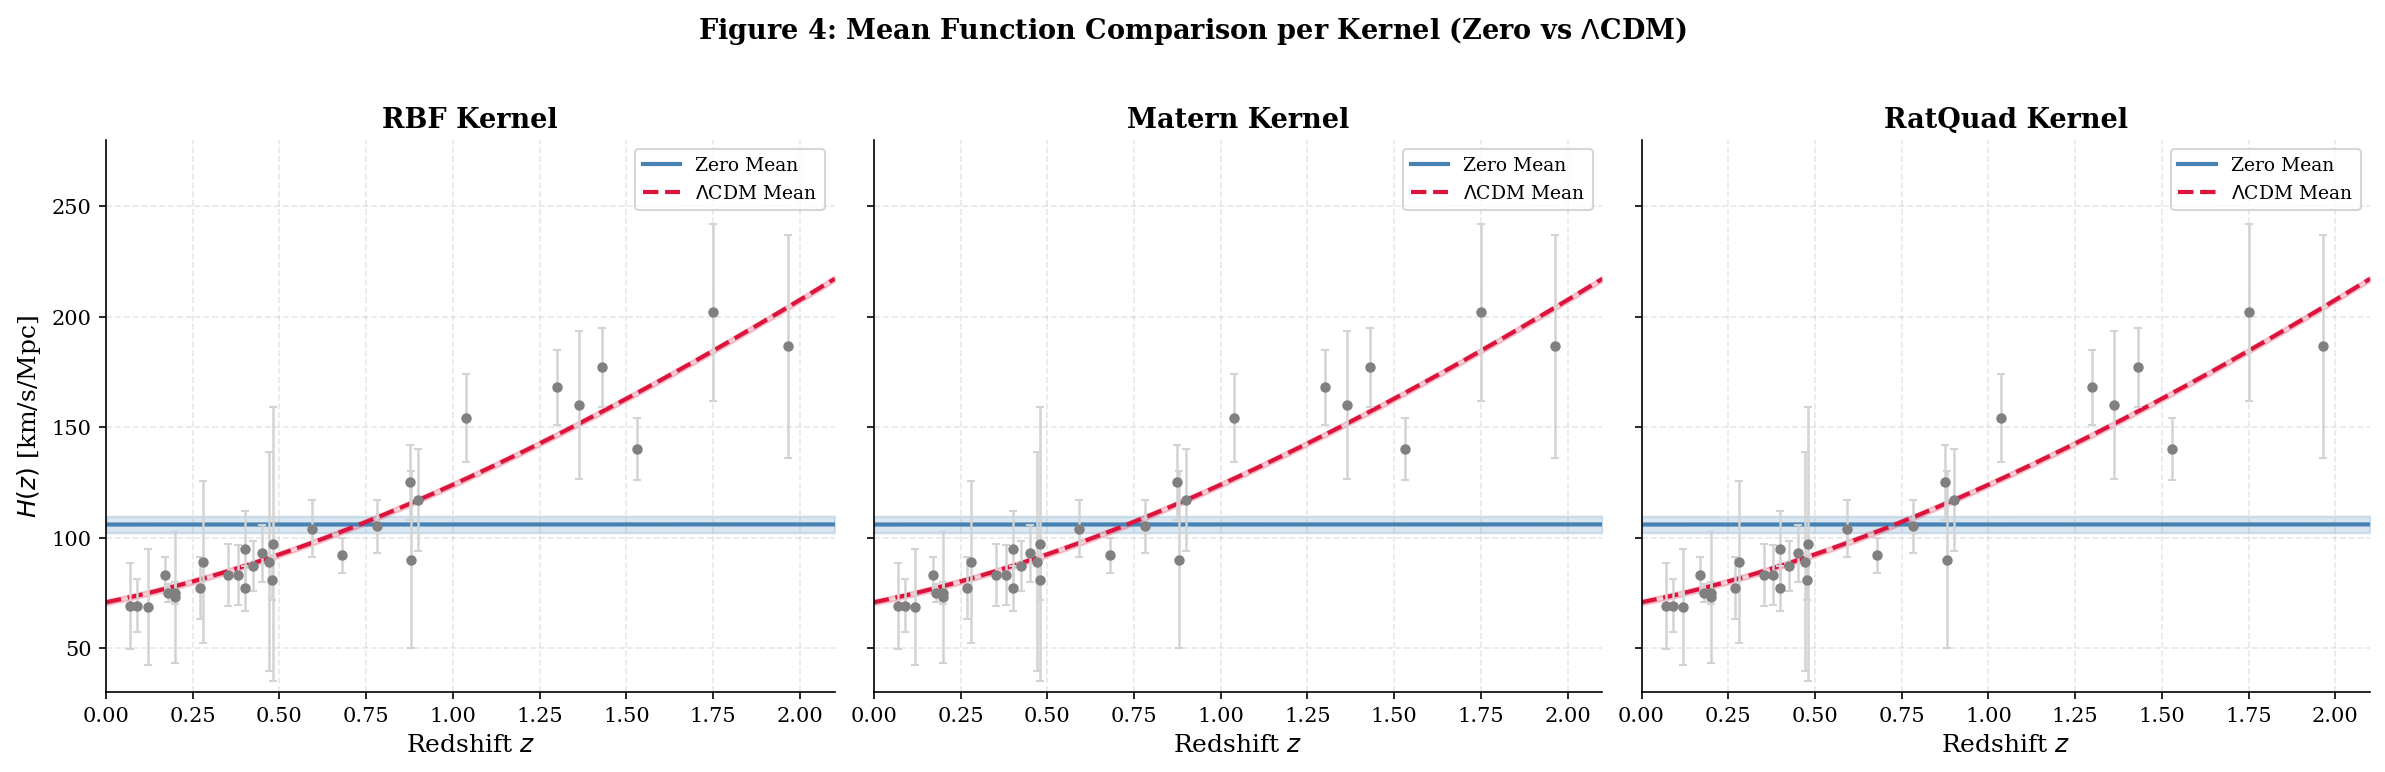

 Figure 4 saved.


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle(r"Figure 4: Mean Function Comparison per Kernel (Zero vs $\Lambda$CDM)",
             fontsize=13, fontweight="bold", y=1.02)

for ax, name in zip(axes, ["RBF", "Matern", "RatQuad"]):
    mu_z, std_z = gpr_zero[name].predict(z_pred, return_std=True)

    mu_r, std_r = gpr_lcdm[name].predict(z_pred, return_std=True)
    mu_l = mu_r + lcdm_mean(z_pred_1d)

    ax.fill_between(z_pred_1d, mu_z - std_z, mu_z + std_z, alpha=0.2, color="steelblue")
    ax.plot(z_pred_1d, mu_z, color="steelblue", lw=2, label="Zero Mean")

    ax.fill_between(z_pred_1d, mu_l - std_r, mu_l + std_r, alpha=0.2, color="crimson")
    ax.plot(z_pred_1d, mu_l, color="crimson", lw=2, linestyle="--", label=r"$\Lambda$CDM Mean")

    ax.errorbar(z_data, Hz_data, yerr=sigma_data,
                fmt="o", color="gray", ecolor="lightgray",
                elinewidth=1.2, capsize=2, ms=4, zorder=5)

    ax.set_title(f"{name} Kernel", fontweight="bold")
    ax.set_xlabel(r"Redshift $z$")
    if ax == axes[0]:
        ax.set_ylabel(r"$H(z)$ [km/s/Mpc]")
    ax.legend(fontsize=9)
    ax.set_xlim(0, 2.1)
    ax.set_ylim(30, 280)

plt.tight_layout()
plt.savefig("Figure4_MeanComparison.png", bbox_inches="tight", dpi=150)
plt.show()
print(" Figure 4 saved.")

## 10 — Bayesian Model Comparison (Table 1)

In [10]:
n = len(z_data)
results = []

for mean_name, gpr_dict in [("Zero", gpr_zero), ("LCDM", gpr_lcdm)]:
    for kernel_name, gpr in gpr_dict.items():
        lml = gpr.log_marginal_likelihood_value_
        k   = len(gpr.kernel_.theta)
        AIC = 2*k - 2*lml
        BIC = k * np.log(n) - 2*lml
        results.append({
            "Mean Function": mean_name, "Kernel": kernel_name,
            "Num Params": k, "LML": round(lml, 4),
            "AIC": round(AIC, 4), "BIC": round(BIC, 4),
        })

print("="*72)
print(f"  TABLE 1: Bayesian Model Comparison — All 6 GPR Models")
print("="*72)
print(f"  {'Mean':>6} | {'Kernel':>10} | {'k':>3} | {'LML':>10} | {'AIC':>10} | {'BIC':>10}")
print("-"*72)
for r in results:
    print(f"  {r['Mean Function']:>6} | {r['Kernel']:>10} | "
          f"{r['Num Params']:>3} | {r['LML']:>10.4f} | "
          f"{r['AIC']:>10.4f} | {r['BIC']:>10.4f}")
print("="*72)

best_lml = max(results, key=lambda x: x["LML"])
best_aic = min(results, key=lambda x: x["AIC"])
best_bic = min(results, key=lambda x: x["BIC"])

print(f"\nBEST MODELS:")
print(f"  Highest LML → {best_lml['Mean Function']} + {best_lml['Kernel']}  (LML = {best_lml['LML']})")
print(f"  Lowest  AIC → {best_aic['Mean Function']} + {best_aic['Kernel']}  (AIC = {best_aic['AIC']})")
print(f"  Lowest  BIC → {best_bic['Mean Function']} + {best_bic['Kernel']}  (BIC = {best_bic['BIC']})")

  TABLE 1: Bayesian Model Comparison — All 6 GPR Models
    Mean |     Kernel |   k |        LML |        AIC |        BIC
------------------------------------------------------------------------
    Zero |        RBF |   2 |  -116.8571 |   237.7142 |   240.5822
    Zero |     Matern |   2 |  -116.8571 |   237.7142 |   240.5822
    Zero |    RatQuad |   3 |  -116.8571 |   239.7142 |   244.0162
    LCDM |        RBF |   2 |  -116.8386 |   237.6771 |   240.5451
    LCDM |     Matern |   2 |  -116.8386 |   237.6771 |   240.5451
    LCDM |    RatQuad |   3 |  -116.8386 |   239.6771 |   243.9791

BEST MODELS:
  Highest LML → LCDM + RBF  (LML = -116.8386)
  Lowest  AIC → LCDM + RBF  (AIC = 237.6771)
  Lowest  BIC → LCDM + RBF  (BIC = 240.5451)


##11 — Infer H₀ and Compare with Planck & SH0ES (Table 2)

In [11]:
H0_planck = 67.4;  sigma_planck = 0.5
H0_shoes  = 73.04; sigma_shoes  = 1.04
z_eval    = np.array([[0.07]])

print("="*75)
print("  TABLE 2: Inferred H₀ from GPR Reconstruction at z = 0.07")
print("="*75)
print(f"  {'Mean':>6} | {'Kernel':>10} | {'H0 (km/s/Mpc)':>15} | "
      f"{'σ_H0':>8} | {'Δ Planck':>10} | {'Δ SH0ES':>10}")
print("-"*75)

H0_results = []

for mean_name, gpr_dict in [("Zero", gpr_zero), ("LCDM", gpr_lcdm)]:
    for kernel_name, gpr in gpr_dict.items():
        mu, std = gpr.predict(z_eval, return_std=True)
        if mean_name == "LCDM":
            mu_H0 = mu[0] + lcdm_mean(np.array([0.07]))[0]
        else:
            mu_H0 = mu[0]
        std_H0 = std[0]

        tension_planck = abs(mu_H0 - H0_planck) / np.sqrt(std_H0**2 + sigma_planck**2)
        tension_shoes  = abs(mu_H0 - H0_shoes)  / np.sqrt(std_H0**2 + sigma_shoes**2)

        H0_results.append({
            "Mean": mean_name, "Kernel": kernel_name,
            "H0": mu_H0, "sigma": std_H0,
            "tension_planck": tension_planck, "tension_shoes": tension_shoes
        })

        print(f"  {mean_name:>6} | {kernel_name:>10} | "
              f"{mu_H0:>15.3f} | {std_H0:>8.3f} | "
              f"{tension_planck:>8.2f}σ | {tension_shoes:>8.2f}σ")

print("="*75)
print(f"\n  Planck 2018: H₀ = {H0_planck} ± {sigma_planck} km/s/Mpc")
print(f"  SH0ES 2022:  H₀ = {H0_shoes} ± {sigma_shoes} km/s/Mpc")

print("\nKEY FINDING:")
for r in H0_results:
    closer = "Planck" if r["tension_planck"] < r["tension_shoes"] else "SH0ES"
    print(f"  {r['Mean']:>6} + {r['Kernel']:>10}: H₀ = {r['H0']:.2f} ± {r['sigma']:.2f}  → closer to {closer}")

  TABLE 2: Inferred H₀ from GPR Reconstruction at z = 0.07
    Mean |     Kernel |   H0 (km/s/Mpc) |     σ_H0 |   Δ Planck |    Δ SH0ES
---------------------------------------------------------------------------
    Zero |        RBF |         105.874 |    3.776 |    10.10σ |     8.38σ
    Zero |     Matern |         105.874 |    3.776 |    10.10σ |     8.38σ
    Zero |    RatQuad |         105.874 |    3.776 |    10.10σ |     8.38σ
    LCDM |        RBF |          73.001 |    1.194 |     4.33σ |     0.02σ
    LCDM |     Matern |          73.001 |    1.194 |     4.33σ |     0.02σ
    LCDM |    RatQuad |          73.001 |    1.194 |     4.33σ |     0.02σ

  Planck 2018: H₀ = 67.4 ± 0.5 km/s/Mpc
  SH0ES 2022:  H₀ = 73.04 ± 1.04 km/s/Mpc

KEY FINDING:
    Zero +        RBF: H₀ = 105.87 ± 3.78  → closer to SH0ES
    Zero +     Matern: H₀ = 105.87 ± 3.78  → closer to SH0ES
    Zero +    RatQuad: H₀ = 105.87 ± 3.78  → closer to SH0ES
    LCDM +        RBF: H₀ = 73.00 ± 1.19  → closer to SH0E

##  12 — Final Ranked Summary (Table 3)

In [23]:
print("="*80)
print("  TABLE 3: All Models Ranked by LML (Best to Worst)")
print("="*80)
print(f"  {'Rank':>4} | {'Mean':>6} | {'Kernel':>10} | "
      f"{'LML':>9} | {'AIC':>9} | {'BIC':>9} | {'H₀':>8} | {'Best?':>8}")
print("-"*80)

merged = []
for r in results:
    h0e = next(x for x in H0_results
               if x["Mean"] == r["Mean Function"] and x["Kernel"] == r["Kernel"])
    merged.append({**r, **h0e})

for rank, r in enumerate(sorted(merged, key=lambda x: x["LML"], reverse=True), 1):
    best = " BEST" if rank == 1 else ""
    print(f"  {rank:>4} | {r['Mean Function']:>6} | {r['Kernel']:>10} | "
          f"{r['LML']:>9.4f} | {r['AIC']:>9.4f} | {r['BIC']:>9.4f} | "
          f"{r['H0']:>7.2f} | {best:>8}")

print("="*80)


  TABLE 3: All Models Ranked by LML (Best to Worst)
  Rank |   Mean |     Kernel |       LML |       AIC |       BIC |       H₀ |    Best?
--------------------------------------------------------------------------------
     1 |   LCDM |        RBF | -116.8386 |  237.6771 |  240.5451 |   73.00 |     BEST
     2 |   LCDM |     Matern | -116.8386 |  237.6771 |  240.5451 |   73.00 |         
     3 |   LCDM |    RatQuad | -116.8386 |  239.6771 |  243.9791 |   73.00 |         
     4 |   Zero |        RBF | -116.8571 |  237.7142 |  240.5822 |  105.87 |         
     5 |   Zero |     Matern | -116.8571 |  237.7142 |  240.5822 |  105.87 |         
     6 |   Zero |    RatQuad | -116.8571 |  239.7142 |  244.0162 |  105.87 |         
